# Squeezing Simulation

This notebook provides the simulation of the escape efficiency, noise spectrum, and so on, related to squeezed states of light.

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch
from matplotlib.transforms import Bbox

In [20]:
import matplotlib
print(matplotlib.__version__)

3.8.4


In [2]:
import os

In [3]:
os.getcwd()

'C:\\Users\\wilan\\PycharmProjects\\SqueezingSimulation\\squeezing'

In [4]:
from utils.plot_style import set_plot_style, AnyObjectHandler
from utils.plot_helper import flip
set_plot_style()

In [5]:
from squeezing.noise_spectrum import noise_spectrum_x, noise_spectrum_p

## Escape Efficiency

We define
$$\eta = \frac{T}{T+L}$$
the escape efficiency, not to be confused by the conversion effiency $\eta$ in the case of SHG, where $T$ is the output coupler transmission and $L$ is the loss, which also should not be confused with the cavity length $L$.
To avoid any confusion, we could name:
- $\eta_{sq}$ the escape efficiency and the other $\eta_{shg}$ conversion efficiency;
- $\mu$ cavity loss and $L$ cavity length

In [6]:
def escape_efficiency(T, L):
    return T / (T + L)

### Numerical simulation

In [7]:
T = np.linspace(start=5, stop=12, num=300, endpoint=True) * 1e-2
# Define the available couplers of the experiment
exact_values = np.array([5, 7, 10, 12]) * 1e-2
# Combine and sort to ensure the exact values are included
T = np.unique(np.concatenate([T, exact_values]))
T.sort()

In [8]:
# Loss 0 to 2%
L = np.linspace(start=1.5, stop=3.0, num=4, endpoint=True) * 1e-2

### Plot

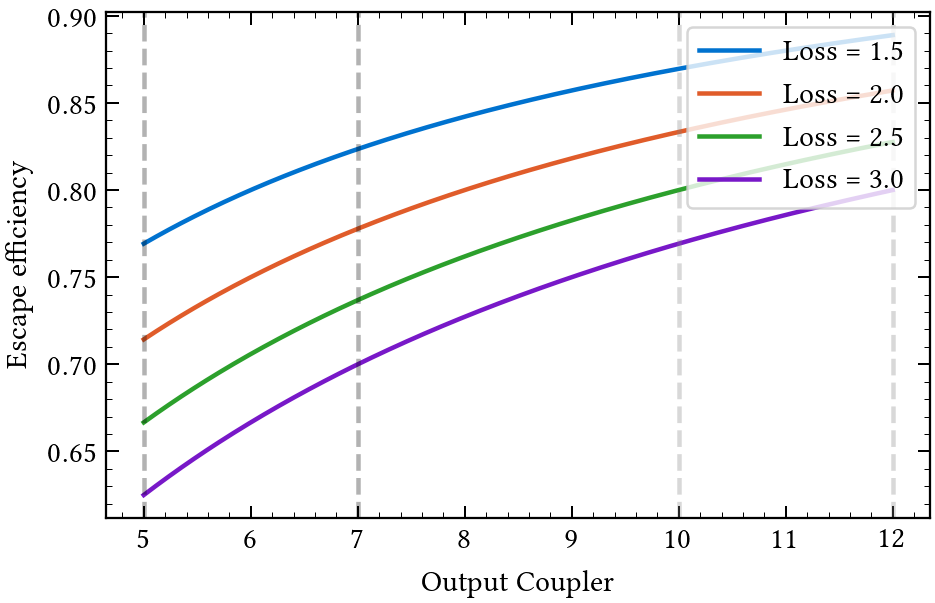

In [10]:
# We want eta vs T for different losses and plot them in the same figure
# We can use a for loop to iterate over the losses and plot the escape efficiency for each loss
fig = plt.figure()
for loss in L:
    eta = escape_efficiency(T, loss)
    plt.plot(T * 1e2, eta, label=f'Loss = {loss*100:.1f}%')
plt.xlabel('Output Coupler')
plt.ylabel('Escape efficiency')

# Vertical lines at 5, 7, 10, 12 coupler value
plt.axvline(x=5, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=7, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=10, color='grey', linestyle='--', alpha=0.3)
plt.axvline(x=12, color='grey', linestyle='--', alpha=0.3)
plt.legend(loc='upper right')
plt.show()

In [12]:
fig.savefig('figure/' + 'escape_efficiency.svg', dpi=300)

## Noise Spectrum

We can either plot the noise spectrum against the normalized pump power $\epsilon^2$ or the wavelength.

### Set parameters

In [9]:
omega_c = 6e10 # 6 MHz bandwidth of the cavity
omega = 0.0 # 0 frequency for pump power
number_points = 2000

In [10]:
# Fix T for different value of Loss
T = 0.07
escape_efficiencies = escape_efficiency(T, L)
# escape_efficiencies = np.linspace(start=0.8, stop=0.96, num=10) # escape efficiency range defined manually

In [11]:
lambda_array = np.linspace(start=0, stop=1000, num=2000) * 1e-9  # wavelength
omega_array = np.linspace(start=0, stop=3*omega_c, num=number_points)
epsilon_array = np.linspace(start=0, stop=1, num=number_points, endpoint=False)  # threshold or pump power

### Pump power

#### Plot

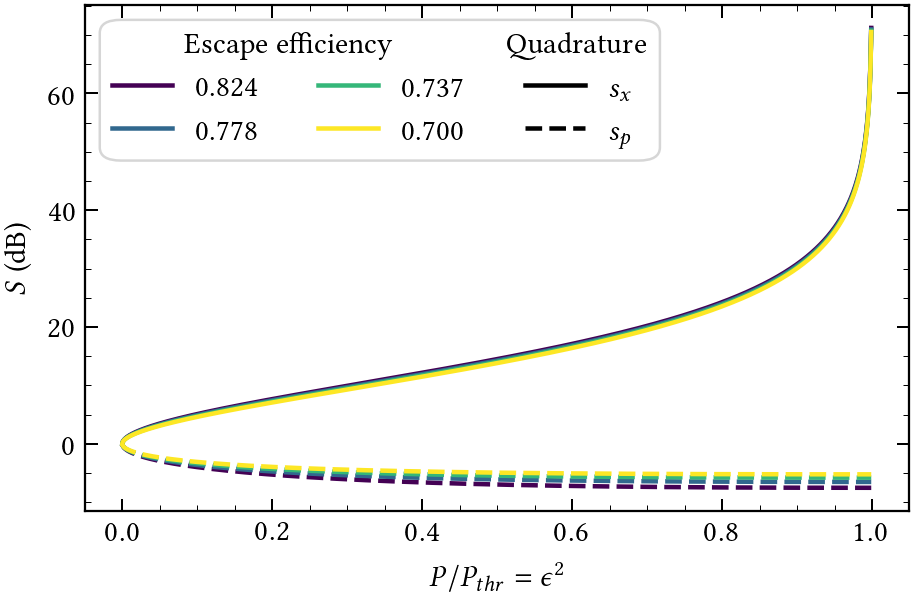

In [99]:
# Colors for each eta (adjust as needed)
colors = plt.cm.viridis(np.linspace(0, 1, len(escape_efficiencies)))

# Create the plot
fig, ax = plt.subplots()

# Plot squeezing (S_p) and anti-squeezing (S_x) for each eta
for idx, eta in enumerate(escape_efficiencies):
    S_x = noise_spectrum_x(omega, omega_c, eta, epsilon_array)
    S_p = noise_spectrum_p(omega, omega_c, eta, epsilon_array)

    # Plot in dB
    ax.plot(epsilon_array**2, 10 * np.log10(S_x), color=colors[idx], linestyle='-')
    ax.plot(epsilon_array**2, 10 * np.log10(S_p), color=colors[idx], linestyle='--')

# Blank handle for padding
blank = Line2D([], [], linestyle="None")

# Left legend (eta values)
eta_handles = [
    Line2D([], [], color=c)
    for c in colors
]
eta_labels = [fr"{eta:.3f}" for eta in escape_efficiencies]

leg1 = ax.legend(
    eta_handles,
    eta_labels,
    loc="upper left",
    frameon=False,
    title="Escape efficiency",
    borderaxespad=0.5,
    ncol=2
)

ax.add_artist(leg1)

# Right legend (quadratures)
quad_handles = [
    Line2D([], [], color="k", ls="-", label=r"$s_x$"),
    Line2D([], [], color="k", ls="--", label=r"$s_p$"),
]

leg2 = ax.legend(
    handles=quad_handles,
    loc="upper left",
    bbox_to_anchor=(0.48, 1.0),  # shift right
    frameon=False,
    title="Quadrature",
    borderaxespad=0.5,
)

leg1.set_zorder(3)
leg2.set_zorder(3)

fig.canvas.draw()
renderer = fig.canvas.get_renderer()

bbox1 = leg1.get_window_extent(renderer)
bbox2 = leg2.get_window_extent(renderer)

bbox = Bbox.union([bbox1, bbox2])

# Clip to the axe extent so the box never overflows
ax_display = ax.get_window_extent(renderer)
clipped = Bbox.intersection(bbox, ax_display)
if clipped is not None:
    bbox = clipped

bbox = bbox.transformed(fig.transFigure.inverted())

rect = FancyBboxPatch(
    (bbox.x0, bbox.y0),
    bbox.width,
    bbox.height,
    boxstyle="Round,pad=0.0001, rounding_size=0.02",
    transform=fig.transFigure,
    facecolor="none",
    edgecolor=(0.8, 0.8, 0.8, 0.8),
    linewidth=1.0,
    zorder=1
)

fig.patches.append(rect)

# Set labels
ax.set_xlabel("$P/P_{thr} = \epsilon^2$")
ax.set_ylabel('$S$ (dB)')
plt.show()

In [100]:
fig.savefig('figure/' + 'noise_spectrum_pump.svg', dpi=300)

### Wavelength

In [101]:
# Fix an epsilon value
epsilon = 0.1
eta = escape_efficiencies[0]

#### Plot

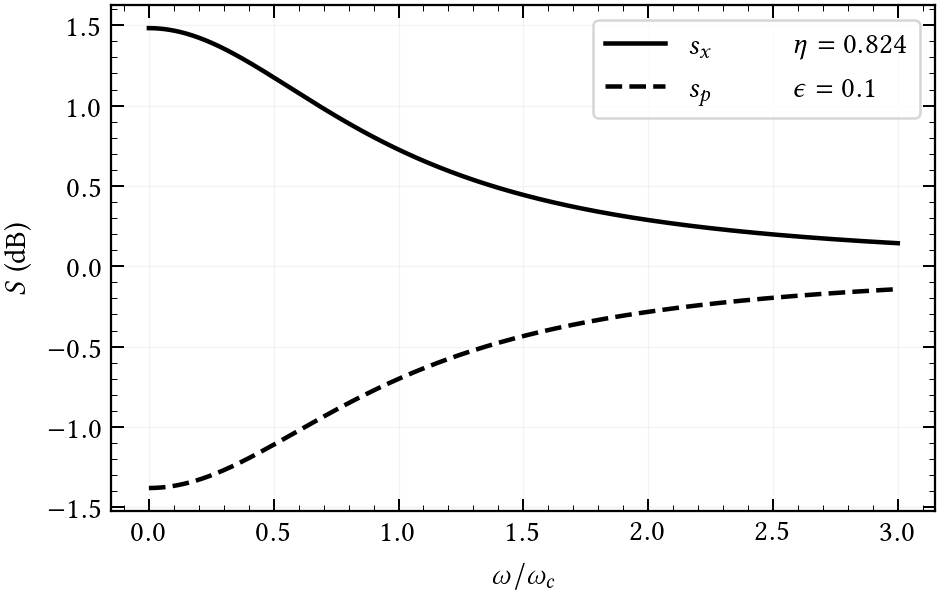

In [102]:
fig, ax = plt.subplots()

sx = noise_spectrum_x(
    omega=omega_array,
    omega_c=omega_c,
    escape_efficiency=eta,
    epsilon=epsilon
)
sp = noise_spectrum_p(
    omega=omega_array,
    omega_c=omega_c,
    escape_efficiency=eta,
    epsilon=epsilon
)

ax.plot(omega_array / omega_c, 10*np.log10(sx), color='k')
ax.plot(omega_array / omega_c, 10*np.log10(sp), color='k', linestyle='--')

ax.set_xlabel(r"$\omega/\omega_c$")
ax.set_ylabel(r"$S$ (dB)")
ax.grid(True)

# --- 2-column legend layout ---
line_handles = [
    # column 1 (lines)
    plt.Line2D([0], [0], color='k', linestyle='-', label=r'$s_x$'),
    plt.Line2D([0], [0], color='k', linestyle='--', label=r'$s_p$'),

    # column 2 (parameters)
    plt.Line2D([], [], color='none', label=fr'$\eta = {eta:.3f}$'),
    plt.Line2D([], [], color='none', label=fr'$\epsilon = {epsilon}$'),
]

ax.legend(
    handles=line_handles,
    ncol=2,
    loc='upper right',
    columnspacing=0.,
    handletextpad=0.8,
    frameon=True
)

plt.show()

In [103]:
fig.savefig('figure/' + 'noise_spectrum_wavelength.svg', dpi=300)